## Multiple Linear Regression 
Regresi dg lebih dari 1 Variabel Independent

In [1]:
from sklearn.datasets import fetch_california_housing

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
housing = fetch_california_housing()

In [4]:
housing.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])

In [5]:
print(housing['DESCR'])

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

    :Number of Instances: 20640

    :Number of Attributes: 8 numeric, predictive attributes and the target

    :Attribute Information:
        - MedInc        median income in block group
        - HouseAge      median house age in block group
        - AveRooms      average number of rooms per household
        - AveBedrms     average number of bedrooms per household
        - Population    block group population
        - AveOccup      average number of household members
        - Latitude      block group latitude
        - Longitude     block group longitude

    :Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived

In [6]:
housing['data'].shape

(20640, 8)

In [7]:
housing['target']

array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894])

In [8]:
housing['target_names'][0]

'MedHouseVal'

In [9]:
housing['feature_names']

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude']

In [10]:
df = pd.DataFrame(data = housing['data'], columns=housing['feature_names'])
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [11]:
target = housing['target_names'][0]

In [12]:
df[target] = housing['target']

In [13]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [14]:
## Quick EDA ==> Data wrangling ==> Tujuannya menyiapkan data untuk Model Machine Learning
## QUICK EDA ==> Features Selection ==> Pemilihan fitur yg akan digunakan untuk Model belajar/training

In [15]:
df.dtypes

MedInc         float64
HouseAge       float64
AveRooms       float64
AveBedrms      float64
Population     float64
AveOccup       float64
Latitude       float64
Longitude      float64
MedHouseVal    float64
dtype: object

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [17]:
df.isna().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

In [18]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [19]:
cfDesc = []
for i in df.columns:
    cfDesc.append([
    i,
    df[i].dtypes,
    df[i].isna().sum(),
    round((df[i].isna().sum()/len(df))*100, 2),
    df[i].nunique(),
    df[i].drop_duplicates().sample(2).values])

In [20]:
pd.DataFrame(data = cfDesc,
            columns=['features',
                    'DataType',
                    'Null',
                    'NullPercentage',
                    'Unique',
                    'Sample'])

,features,DataType,Null,NullPercentage,Unique,Sample
0,MedInc,float64,0,0.0,12928,"[3.5781, 4.1776]"
1,HouseAge,float64,0,0.0,52,"[19.0, 8.0]"
2,AveRooms,float64,0,0.0,19392,"[4.02, 4.176691729323308]"
3,AveBedrms,float64,0,0.0,14233,"[1.0504527813712807, 1.3149171270718232]"
4,Population,float64,0,0.0,3888,"[5558.0, 248.0]"
5,AveOccup,float64,0,0.0,18841,"[3.6443298969072164, 2.6036585365853657]"
6,Latitude,float64,0,0.0,862,"[40.86, 38.6]"
7,Longitude,float64,0,0.0,844,"[-124.05, -120.71]"
8,MedHouseVal,float64,0,0.0,3842,"[2.603, 0.753]"


In [21]:
import warnings
warnings.filterwarnings('ignore')

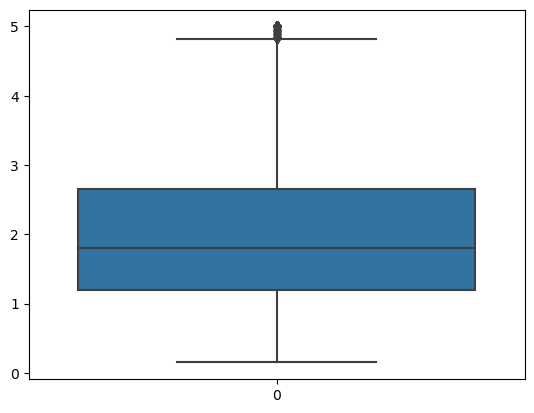

In [22]:
sns.boxplot(df['MedHouseVal']);

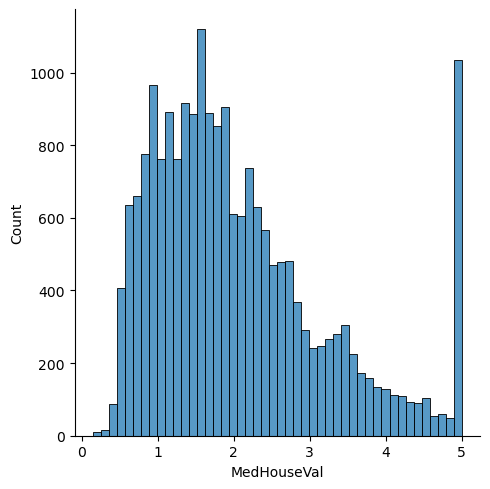

In [23]:
sns.displot(df['MedHouseVal']);

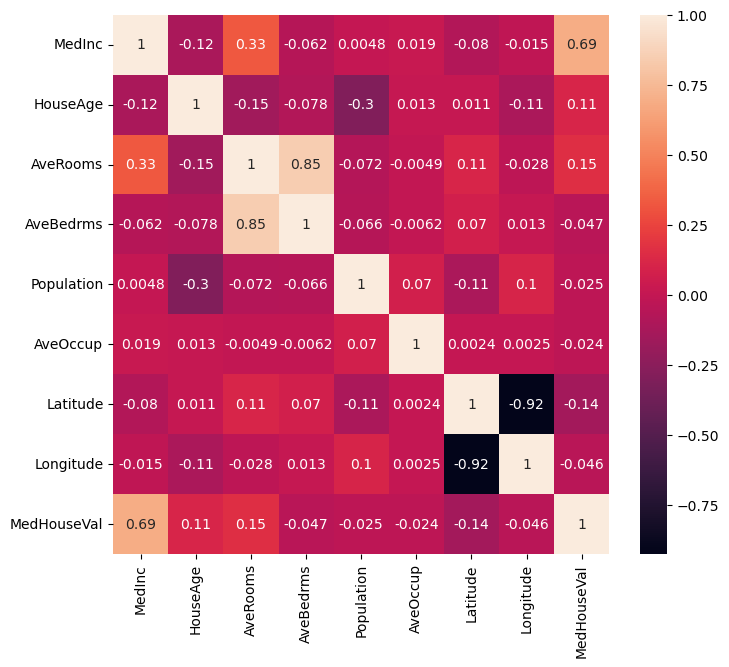

In [24]:
### Cek Korelasi ==> salah satu metode untuk Features Selection
## Pearson
plt.figure(figsize=(8,7))
sns.heatmap(df.corr(), annot=True);

## Feature Selection
- Memilih features yg akan digunakan untuk Training Model (Model Belajar)
- Salah satu cara/metode yg digunakan adalah dg menggunakan Korelasi
- Umumnya menggunakan kolom yg memiliki Korelasi antara atau lebih dari -0.5 s/d 0.5 atau disesuaikan dg kondisi

In [25]:
df.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='object')

In [26]:
df = df.drop(columns=['Population', 'Longitude', 'AveOccup'])

In [27]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Latitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,37.88,4.526
1,8.3014,21.0,6.238137,0.971880,37.86,3.585
2,7.2574,52.0,8.288136,1.073446,37.85,3.521
3,5.6431,52.0,5.817352,1.073059,37.85,3.413
4,3.8462,52.0,6.281853,1.081081,37.85,3.422


In [28]:
## Tentukan Features & Target ==> Soal & Jawaban
X = df.drop(columns='MedHouseVal')
y = df['MedHouseVal']

In [29]:
## Machine Learning
- Tujuan membuat Machine Learning ==> Bisa memprediksi / Menjawab Soal / Data Baru 
- Data Baru ==> Data yg tidak ada di dataset
- Data Baru ==> Data yg belum dipelajari oleh Model
- Data Baru ==> Data yg sama sekali belum "dilihat" Model, Belum diketahui oleh Model

Model Belajar ==> Model mempelajari Pattern yg ada pada data ==> Training Model
Proses Training Model ==> .fit(X, y) ==> .fit(Features, Target) ==> .fit(Soal, Jawaban)

Soal ==> Kolom Features ==> X
Jawaban ==> Kolom target ==> y

### Evaluation Metrics
- Penilaian sebaik apa model kita
- Membandingkan Jawaban Model dg Kunci jawaban
- Kunci Jawaban ==> Data Aktual yg kita punya (data target)
- Jawaban Model ==> Prediksi dari Model

### Splitting Data
Dataset yg ada kita bagi/split/potong jadi 2
- Data untuk Training/Belajar
- Data untuk Testing/Validasi ==> Data digunakan sebagai Simulasi Data Baru

Data untuk Training/Train data ==> Data yg akan dipelajari Pattern nya oleh Model, Model sudah tau/Melihat Isi dari Features - Target nya.
Data untuk Testing/Test Data ==> Data yg sama sekali belum dilihat - dipelajari oleh Model dan akan diprediksi sebagai Simulasi Data Baru

Dataset (100%)
Akan dipisah menjadi
Data Training 80% ==> Data yg akan dipelajari Model ==> data digunakan untuk belajar ==> Latihan Try Out ==> Model mempelajari Pattern antara Features & Target

Data Testing 20% ==> Data yg akan digunakan untuk Ujian sesungguhnya karena merupakan simulasi Data baru ==> Evaluation Metrics Utama/Penilaian sesungguhnya

Distribusi Train dan Test ==> Cari yg Ideal - Proporsional ==> 70% - 80% untuk Train, 15-30% untuk Test
Jumlah Train + Test = 100%
train 73%
test 27%

SyntaxError: invalid syntax (3552328921.py, line 2)

## Splitting Dataset

In [30]:
## Tentukan Features & Target ==> Soal & Jawaban
X = df.drop(columns='MedHouseVal') ## Features / Soal
y = df['MedHouseVal'] ## Target / Jawaban

In [31]:
from sklearn.model_selection import train_test_split

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.15, random_state = 999)

In [33]:
X = Kolom features
y = Kolom target
test_size = .15 ==> Proporsi data yg akan digunakan untuk testing ==> 0.15 ==> 15%
Sisanya akan otomatis digunakan sebagai data training ==> 85%
Ada 2 Opsi yg bisa kita gunakan , kita bisa pake parameter train_size = atau test_size = (Pilih salah satu)
Untuk isinya juga ada 2 opsi, Jumlah langsung baris datanta atau persentase datanya.

Misal
train_size = 500 ==> 500 baris data yg akan digunakan untuk Training
train_size = .75 ==> 75% dari total data (baris data) akan digunakan untuk Training

Proses Splitting data (data untuk train dan test) dilakukan secara random

random_state => angka integer => Digunakan untuk mengunci Randomness, sehingga random yg dilakukan hanya sekali, Nilai random_state bebas asal Integer

SyntaxError: invalid syntax (921760497.py, line 1)

In [34]:
X_train.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Latitude
19273,3.8244,14.0,5.865952,1.068365,38.44
3006,5.1457,5.0,6.395918,1.023469,35.22
16921,3.4333,27.0,3.443080,0.977679,37.57
10074,4.3958,9.0,6.645631,1.237864,39.33
15842,4.6547,52.0,4.567340,1.050505,37.74


In [35]:
X_train.head() ## Data Soal untuk Belajar dan Try Out

,MedInc,HouseAge,AveRooms,AveBedrms,Latitude
19273,3.8244,14.0,5.865952,1.068365,38.44
3006,5.1457,5.0,6.395918,1.023469,35.22
16921,3.4333,27.0,3.443080,0.977679,37.57
10074,4.3958,9.0,6.645631,1.237864,39.33
15842,4.6547,52.0,4.567340,1.050505,37.74


In [36]:
X_test.head() ## Data SOal untuk Simulasi Ujian yg sesungguhnya

,MedInc,HouseAge,AveRooms,AveBedrms,Latitude
2374,3.7261,7.0,5.717532,1.003247,36.70
13150,4.6477,27.0,6.098214,1.241071,36.92
16857,3.1058,32.0,3.936334,1.010977,37.62
6787,2.8062,27.0,5.065445,1.204188,34.09
19109,3.0139,45.0,4.796610,1.067797,38.23


In [37]:
y_train.head() ## Kunci Jawaban untuk Soal Try Out

19273    1.800
3006     1.182
16921    2.900
10074    1.248
15842    3.257
Name: MedHouseVal, dtype: float64

In [38]:
y_test.head() ## Kunci Jawaban untuk Simulasi Ujian sesungguhnya

2374     0.839
13150    2.659
16857    2.530
6787     1.928
19109    1.941
Name: MedHouseVal, dtype: float64

In [39]:
X_train.shape

(17544, 5)

In [40]:
X_test.shape

(3096, 5)

## Machine Learning Modelling

In [41]:
from sklearn.linear_model import LinearRegression

In [42]:
Model = LinearRegression()

In [43]:
Model.fit(X_train, y_train)
## Model Belajar ==> Mencari Pattern dari Soal - Jawaban (Dari Features - Target) Data Training

LinearRegression()

In [44]:
## Quick Evaluation Metrics

In [45]:
Model.score(X_train, y_train) ## Melakukan Penilaian / Evaluation Metrics Train set

0.5344467143124487

In [46]:
Model.score(X_test, y_test) ## Melakukan Penilaian / Eva Metrics Test Set

0.573949399448278

In [47]:
## Evaluation Metrics
Data Training (data yg dipelajari Model) ==> data yg digunakan untuk Model mencari Pattern => Try Out => Evaluation metrics
Data Testing (Simulasi ujian sesungguhnya/ Data yg sama sekali belum dilihat oleh Model) => Evaluation Metrics

Data yg dipelajari/Dilihat/Diketahui ==> adalah data yg masuk ke dalam .fit(Data)

## Kondisi Penilaian berdasarkan Hasil Evaluation Metrics untuk Data Train dan Data Test
> UnderFitting ==> Dua-dua nya jelek => Nilai Eva Metrics untuk Data training maupun Data testing sama-sama jelek
> Overfitting ==> Nilai Eva metrics untuk Data Training Bagus tapi untuk data testing Jelek ==> Model terlalu Menghafal bukan mencari Pattern ==> Ada perbedaan Signifikan antara nilai eva metrics Training dan Testing
Ada selisih sekitar lebih dari 5 poin
Misal Eva metrics Train ==> 80, EVa metrics Test ==> 72 ==> Ada selisih 8 poin ==> OverFitting => Model terlalu Menghafal
> Fit ==> Nilai Eva metrics untuk Training dan Testing bagus ==> Tidak ada perbedaan signifikan antara nilai eva metrics Training & Testing
Eva metrics Train => 85, Eva Metrics Test => 83
Jika Nilai Eva Metrics Test Lebih Bagus dibanding Eva metrics Train (Meskipun jarang terjadi)


Misal ada Kasus
Model A
Eva metrics Train ==> 93
Eva metrics Test ==> 82

Model B
Eva metrics Train ==> 84
Eva metrics Test ==> 81

Kita akan memilih Model B, Karena lebih Fit dan Stabil
Model A => Overfitting

SyntaxError: invalid syntax (3936834070.py, line 2)

In [48]:
## Evaluation Metrics
- Membandingkan "Kunci Jawaban" /Data Target Aktual dengan Jawaban Model - Jawaban Prediksi Model

y_true ==> Data target Aktual ==> Bisa dari y_train atau y_test ==> Tergantung Evaluation Metrics mana yg mau diukur
y_pred ==> Data Target Prediksi ==> Didapat dari Model menjawab Soal/Prediksi dari X_train maupun X_test

SyntaxError: invalid syntax (1675375635.py, line 2)

In [49]:
Model.predict(X_train) ## Model menjawab Soal yg berasal dari Data Train ==> Try Out

array([1.61312478, 2.12068289, 2.01650556, ..., 2.54055363, 1.35881249,
       1.10105777])

In [50]:
Model.predict(X_test) ## Model men jawab Soal yg berasal dari Data Test ==> Ujian Simulasi data baru 

array([1.47746932, 2.40302912, 1.86102558, ..., 2.06201088, 2.55197607,
       1.06687039])

In [51]:
pred_train = Model.predict(X_train)

In [52]:
pred_test = Model.predict(X_test) 

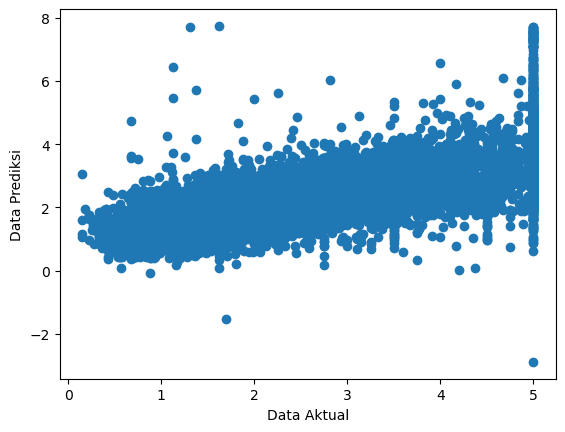

In [53]:
plt.scatter(y_train, pred_train)
plt.xlabel("Data Aktual")
plt.ylabel("Data Prediksi")
plt.show()

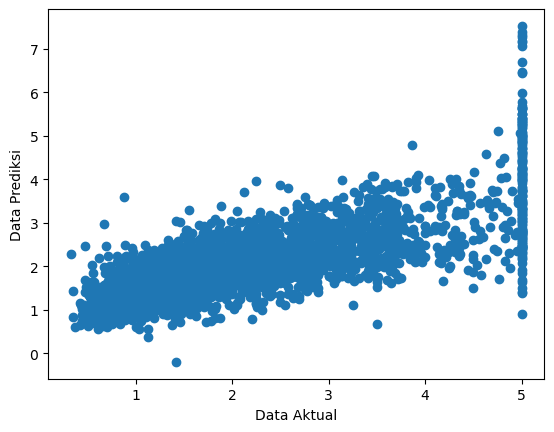

In [54]:
plt.scatter(y_test, pred_test)
plt.xlabel("Data Aktual")
plt.ylabel("Data Prediksi")
plt.show()

In [55]:
## Analisis Error untuk Training Set

In [56]:
Train_set = pd.concat([X_train, y_train], axis=1)
Train_set.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Latitude,MedHouseVal
19273,3.8244,14.0,5.865952,1.068365,38.44,1.800
3006,5.1457,5.0,6.395918,1.023469,35.22,1.182
16921,3.4333,27.0,3.443080,0.977679,37.57,2.900
10074,4.3958,9.0,6.645631,1.237864,39.33,1.248
15842,4.6547,52.0,4.567340,1.050505,37.74,3.257


In [57]:
Train_set['Val_Predict'] = pred_train

In [58]:
Train_set.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Latitude,MedHouseVal,Val_Predict
19273,3.8244,14.0,5.865952,1.068365,38.44,1.800,1.613125
3006,5.1457,5.0,6.395918,1.023469,35.22,1.182,2.120683
16921,3.4333,27.0,3.443080,0.977679,37.57,2.900,2.016506
10074,4.3958,9.0,6.645631,1.237864,39.33,1.248,1.805904
15842,4.6547,52.0,4.567340,1.050505,37.74,3.257,2.893524


In [59]:
Train_set['Error'] = abs(Train_set['MedHouseVal'] - Train_set['Val_Predict'])

In [60]:
Train_set.sort_values('Error', ascending=False)

,MedInc,HouseAge,AveRooms,AveBedrms,Latitude,MedHouseVal,Val_Predict,Error
1914,1.8750,33.0,141.909091,25.636364,38.91,5.00001,-2.891675,7.891685
18501,15.0001,52.0,8.461538,1.230769,37.19,1.31300,7.709648,6.396648
1979,4.6250,34.0,132.533333,34.066667,38.80,1.62500,7.744997,6.119997
11912,12.5381,29.0,6.888889,1.222222,33.96,1.12500,6.458777,5.333777
6688,0.4999,28.0,7.677419,1.870968,34.15,5.00001,0.615260,4.384750
...,...,...,...,...,...,...,...,...
19176,4.5588,17.0,6.053691,1.020134,38.43,1.96400,1.964217,0.000217
14165,2.6500,38.0,4.688797,0.946058,32.77,1.67600,1.676096,0.000096
11617,3.6442,17.0,4.584586,1.041353,33.80,1.93100,1.931036,0.000036
20077,2.5729,16.0,5.241259,1.139860,38.04,1.18800,1.188027,0.000027


In [61]:
Train_set['MedHouseVal'].mean()

2.064352144322845

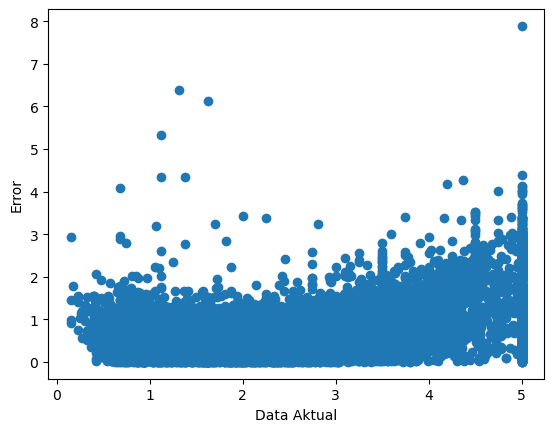

In [62]:
plt.scatter(Train_set['MedHouseVal'], Train_set['Error'])
plt.xlabel("Data Aktual")
plt.ylabel("Error")
plt.show()

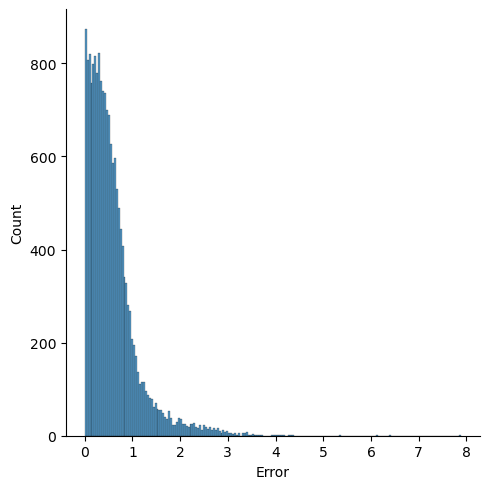

In [63]:
sns.displot(Train_set['Error'])
plt.show()

In [64]:
## Distribusi Error yg baik adalah yg memiliki rata-rata error = 0
Train_set['Error'].mean()

0.5761165935615901

In [65]:
Train_set.sort_values('Error', ascending=False).head(10)

,MedInc,HouseAge,AveRooms,AveBedrms,Latitude,MedHouseVal,Val_Predict,Error
1914,1.8750,33.0,141.909091,25.636364,38.91,5.00001,-2.891675,7.891685
18501,15.0001,52.0,8.461538,1.230769,37.19,1.31300,7.709648,6.396648
1979,4.6250,34.0,132.533333,34.066667,38.80,1.62500,7.744997,6.119997
11912,12.5381,29.0,6.888889,1.222222,33.96,1.12500,6.458777,5.333777
6688,0.4999,28.0,7.677419,1.870968,34.15,5.00001,0.615260,4.384750
19006,10.2264,45.0,3.166667,0.833333,38.32,1.37500,5.725989,4.350989
4492,10.2264,52.0,4.800000,0.600000,34.06,1.12500,5.461168,4.336168
1913,4.0714,19.0,61.812500,11.000000,39.01,4.37500,0.096754,4.278246
18681,2.1719,17.0,28.600000,4.945455,36.86,4.20000,0.020589,4.179411
16642,0.7025,19.0,2.425197,1.125984,35.30,5.00001,0.866942,4.133068


In [66]:
## Lakukan analisa error dg memperhatikan
Kesamaan nilai dari fitur
- Misal :
    - Error tinggi kebanyakan terjadi jika AveBedrms diatas 10 dan AveRooms diatas 15
    - Kita Drop data yg memiliki AveBedrms diatas 10 dan AveRooms diatas 15
    - Proses ini kita sebut sebagai Salah satu Project Limitation

SyntaxError: invalid syntax (1676214050.py, line 2)

## Evaluation Metrics Regression
- R Squared
- MAE
- MSE
- RMSE
- Optional Jika banyak Error yg Outliers => MedAE

## R-Squared
- Koefisien Determinan
- Mengukur seberapa bagus model kita
- Persentase Informasi dari nilai Y (target-dependent variabel) yg terkandung di dalam X (Features-Independent Var)
- Analogi : Berapa persen Buah mangga yg bisa kita makan Ketika kita mengupas Mangga
- Range : -infinite s/d 1
- Nilai Negatif berarti model lebih jelek dibandingkan dg ketika kita menebak/Memprediksi Nilai berdasarkan rata-rata target
- Nilai Positif berarti model lebih bagus dibandingkan dg ketika kita menebak/Memprediksi Nilai berdasarkan rata-rata target
- Semakin mendekati Satu, semakin Bagus

## MAE (Mean Absolute Error)
- Rata-rata Error yg sudah diAbsolutkan (dimutlakkan)
- Range : 0 s/d Infinite
- Satuannya sama dengan satuan data target
- Mendekati NOL Semakin bagus
- Untuk mengetahui Error sudah cukup baik atau masih terlalu besar, Bandingkan dg rata-rata target

## MSE (Mean Squared Error)
- Rata-rata Error yg sudah dikuadratkan
- Range : 0 s/d Infinite
- Memberikan Bobot terhadap error
- Semakin tinngi Error semakin tinggi/besar bobotnya
- Memberikan Penalti terhadap **error yg besar**
- Semakin mendekati NOL, semakin bagus

## RMSE (Root Mean Squared Error)
- Akar Kuadrat dari MSE
- Versi standarisasi dari MSE
- MSE => Variance, RMSE => Standar Deviasi
- Range : 0 s/d Infinite
- Memberikan Bobot terhadap Error
- Memberikan Penalti terhadap error yg besar
- Mendekati NOL Semakin bagus
- Jenis Eva metrics yg paling umum digunakan di kasus Regresi, termasuk yg sering digunakan dalam Kompetisi Kaggle

## MedAE (Median Absolute Error)
- Sama seperti MAE, hanya menggunakan nilai Median dari Error (bukan mean)
- Digunakan jika ada Outliers pada Error

In [67]:
-10 * -10

100

In [68]:
Error (Absolut)
4
6
10
3
4
5
Jika di absolutkan ==> selisih antara error 4 dan error hanya 2 dan dengan error 10 hanya 6

SyntaxError: invalid syntax (3867648068.py, line 8)

In [69]:
Error Kuadrat
16
36
100
9
16
25

Selisih antara Error 16 dan 36 ada 20 point dan dengan error 100 ada 84 point

SyntaxError: invalid syntax (785562026.py, line 1)

In [70]:
100-16

84

In [71]:
Project A ==> Memprediksi Jumlah Penyewaan Motor
Rata-rata Jumlah penyewaan motor (rata-rata data aktual) ==> 75
MAE = 50

Project B ==> Memprediksi harga SportsCar
Rata-rata harga/target ==> 3.500.000.000
MAE = 500.000

SyntaxError: invalid syntax (2641369686.py, line 1)

In [72]:
Project A
Data Aktual => 75
Model akan prediksi antara 125 atau 25

SyntaxError: invalid syntax (1219180761.py, line 1)

In [73]:
50/75

0.6666666666666666

In [74]:
# Project B
500000/3500000000

0.00014285714285714287

Meskipun nilai MAE dari project B sangat jauh jika dibanding project A, tetapi sebenarnya Project B jauh lebih bagus dibanding project A

## Evaluation Metrics Calculation

In [75]:
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

In [76]:
### Evaluation untuk Data Training

In [77]:
y_train.head() ## Kunci jawaban Training

19273    1.800
3006     1.182
16921    2.900
10074    1.248
15842    3.257
Name: MedHouseVal, dtype: float64

In [78]:
pred_train = Model.predict(X_train)
## Model menjawab soal try out ==> Memprediksi data training

In [79]:
r2_train = r2_score(y_train, pred_train)
r2_train

0.5344467143124487

In [80]:
MAE_train = mean_absolute_error(y_train, pred_train)
MAE_train

0.5761165935615901

In [81]:
MSE_train = mean_squared_error(y_train, pred_train)
MSE_train

0.6154824387407303

In [82]:
RMSE_train = np.sqrt(MSE_train)
RMSE_train

0.7845268884752965

In [83]:
print("Hasil Evaluation Metrics untuk Data Training")
print("=" * 50)
print("Nilai R Squared : ", r2_train.round(2))
print("Nilai MAE : ", MAE_train.round(2))
print("Nilai MSE : ", MSE_train.round(2))
print("Nilai RMSE : ", RMSE_train.round(2))

Hasil Evaluation Metrics untuk Data Training
Nilai R Squared :  0.53
Nilai MAE :  0.58
Nilai MSE :  0.62
Nilai RMSE :  0.78


In [84]:
### Evaluation untuk Data Testing / Simulasi Ujian Sesungguhnya

In [85]:
y_test ## Kunci jawaban ujian sesungguhnya

2374     0.83900
13150    2.65900
16857    2.53000
6787     1.92800
19109    1.94100
          ...   
495      3.76900
8793     5.00001
4475     1.58500
17680    2.12800
12745    1.43400
Name: MedHouseVal, Length: 3096, dtype: float64

In [86]:
pred_test = Model.predict(X_test)
## Model menjawab ujian sesungguhnya ==> Model memprediksi data testing

In [87]:
r2_test = r2_score(y_test, pred_test)
r2_test

0.573949399448278

In [88]:
MAE_test = mean_absolute_error(y_test, pred_test)
MAE_test

0.5663941302606417

In [89]:
MSE_test = mean_squared_error(y_test, pred_test)
MSE_test

0.5899713554619727

In [90]:
RMSE_test = np.sqrt(MSE_test)
RMSE_test

0.7680959285544825

In [91]:
print("Hasil Evaluation Metrics untuk Data Testing")
print("=" * 50)
print("Nilai R Squared : ", r2_test.round(2))
print("Nilai MAE : ", MAE_test.round(2))
print("Nilai MSE : ", MSE_test.round(2))
print("Nilai RMSE : ", RMSE_test.round(2))

Hasil Evaluation Metrics untuk Data Testing
Nilai R Squared :  0.57
Nilai MAE :  0.57
Nilai MSE :  0.59
Nilai RMSE :  0.77


In [92]:
data = {
"Training" : [r2_train.round(2), MAE_train.round(2), MSE_train.round(2), RMSE_train.round(2) ],
"Testing" : [r2_test.round(2), MAE_test.round(2), MSE_test.round(2), RMSE_test.round(2)]}

In [93]:
pd.DataFrame(data, index=["R Squared", "MAE", "MSE", "RMSE"])

,Training,Testing
R Squared,0.53,0.57
MAE,0.58,0.57
MSE,0.62,0.59
RMSE,0.78,0.77


In [94]:
print(Model.score(X_train, y_train)) 
print(Model.score(X_test, y_test)) 
### Ketika kita menggunakan score, pada kasus regresi, nilai yg ditampilkan adalah Nilai R Squared

0.5344467143124487
0.573949399448278


In [95]:
Y = ax + b


NameError: name 'ax' is not defined

In [ ]:
Model.intercept_

In [ ]:
Model.coef_

In [96]:
X_train.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Latitude'], dtype='object')

In [97]:
pd.DataFrame(data = Model.coef_, index= X_train.columns, columns = ['Coef'])

,Coef
MedInc,0.518883
HouseAge,0.015790
AveRooms,-0.187074
AveBedrms,0.882114
Latitude,-0.031931


In [98]:
Y = a*x + b*x2 + c*x3 + d*x4 + e*x5 + Z
Z = Konstanta / Intercept
a,b,c,d,e ==> Nilai Koefisien
x, x2, x3, x4, x5 ==> Nilai Variabel

Harga Prediksi = Y

Y = a*MedInc + b*HouseAge - c*AveRooms + d*AveBedrms -e*Latitude + Intercept
a,b,c,d,e ==> Nilai Koefisien
Menunjukkan Sebab - Akibat

SyntaxError: invalid syntax (1797447559.py, line 3)

In [99]:
X_train.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Latitude
19273,3.8244,14.0,5.865952,1.068365,38.44
3006,5.1457,5.0,6.395918,1.023469,35.22
16921,3.4333,27.0,3.443080,0.977679,37.57
10074,4.3958,9.0,6.645631,1.237864,39.33
15842,4.6547,52.0,4.567340,1.050505,37.74


In [100]:
(2 * 0.51) + 0.79

1.81

In [101]:
Model.predict([[2, 0, 0, 0, 0]])

array([1.8277837])

In [102]:
Model.predict([[4.5, 10, 3.5, 2.5, 30]])
## Memprediksi Data Baru
## Data yg tidak ada di Dataset

array([3.87549029])

In [103]:
Model.intercept_ ## Harga default ==> Harga ketika semua nilai variabel nya NOL

0.7900182499353146

In [104]:
Model.predict([[0, 0, 0, 0, 0]])

array([0.79001825])

In [105]:
Model = LinearRegression(fit_intercept=False)
## Ketika fit_intercept = False, maka nilai Konstanta = 0, sehingga ketika nilai seluruh features = 0, nilai target/y = 0
## Misal nya harga rumah => Jika Luas tanah =0, luas bangunan =0, jumlah kamar = 0, dst, maka Harga = 0
## Penggunaan fit_intercept True atau False, tergantung dari Independent Variabel dan Kasus bisnisnya

## Improvement Machine Learning

## Improvement Menggunakan Features Engineering (Polynomial Features)

In [106]:
from sklearn.preprocessing import PolynomialFeatures

In [107]:
y_train

19273    1.800
3006     1.182
16921    2.900
10074    1.248
15842    3.257
         ...  
8417     1.523
5832     3.289
16865    2.154
13157    1.459
12636    0.680
Name: MedHouseVal, Length: 17544, dtype: float64

In [108]:
X = df.drop(columns='MedHouseVal')
y = df['MedHouseVal']

In [133]:
Poli = PolynomialFeatures(degree=4, include_bias=False, interaction_only=True)

In [134]:
X_PF = Poli.fit_transform(X)

In [135]:
X_train_PF, X_test_PF, y_train, y_test = train_test_split(X_PF, y, train_size=.80, random_state = 42)

In [112]:
X_PF

array([[8.32520000e+00, 4.10000000e+01, 6.98412698e+00, ...,
        1.32375517e+04, 2.25494492e+03, 1.11051676e+04],
       [8.30140000e+00, 2.10000000e+01, 6.23813708e+00, ...,
        6.41451921e+03, 1.90545953e+03, 4.82022913e+03],
       [7.25740000e+00, 5.20000000e+01, 8.28813559e+00, ...,
        1.53331231e+04, 2.44390391e+03, 1.75108170e+04],
       ...,
       [1.70000000e+00, 1.70000000e+01, 5.20554273e+00, ...,
        1.27637551e+03, 3.90836897e+02, 3.90836897e+03],
       [1.86720000e+00, 1.80000000e+01, 5.32951289e+00, ...,
        1.55305917e+03, 4.59836048e+02, 4.43286679e+03],
       [2.38860000e+00, 1.60000000e+01, 5.25471698e+00, ...,
        1.74877392e+03, 5.74332001e+02, 3.84715399e+03]])

In [113]:
X_trainPoli = Poli.transform(X_train)

In [114]:
X_testPoli = Poli.transform(X_test)

In [115]:
### Model Training Polynomial Regression

In [116]:
Model_PF = LinearRegression()

In [117]:
Model_PF.fit(X_train_PF, y_train)

NameError: name 'X_train_PF' is not defined

In [118]:
PF_train = Model_PF.predict(X_train_PF)
PF_test = Model_PF.predict(X_test_PF)

NameError: name 'X_train_PF' is not defined

## Evaluation Metrics Comparison

In [119]:
## Polynomial Features

In [120]:
## Training set

In [121]:
r2_PF = r2_score(y_train, PF_train)
r2_PF

NameError: name 'PF_train' is not defined

In [122]:
MAE_PF = mean_absolute_error(y_train, PF_train)
MAE_PF

NameError: name 'PF_train' is not defined

In [123]:
MSE_PF = mean_squared_error(y_train, PF_train)
MSE_PF

NameError: name 'PF_train' is not defined

In [124]:
RMSE_PF = np.sqrt(MSE_PF)
RMSE_PF

NameError: name 'MSE_PF' is not defined

In [125]:
## Testing Set

In [126]:
r2_PF_test = r2_score(y_test, PF_test)
r2_PF_test

NameError: name 'PF_test' is not defined

In [127]:
MAE_PF_test = mean_absolute_error(y_test, PF_test)
MAE_PF_test

NameError: name 'PF_test' is not defined

In [128]:
MSE_PF_test = mean_squared_error(y_test, PF_test)
MSE_PF_test

NameError: name 'PF_test' is not defined

In [129]:
RMSE_PF_test = np.sqrt(MSE_PF_test)
RMSE_PF_test

NameError: name 'MSE_PF_test' is not defined

In [130]:
eva_data = {
"LinReg Training" : [r2_train.round(2), MAE_train.round(2), MSE_train.round(2), RMSE_train.round(2) ],
"LinReg Testing" : [r2_test.round(2), MAE_test.round(2), MSE_test.round(2), RMSE_test.round(2)],
"Polynomial Training" : [r2_PF.round(2), MAE_PF.round(2), MSE_PF.round(2), RMSE_PF.round(2) ],
"Polynomial Testing" : [r2_PF_test.round(2), MAE_PF_test.round(2), MSE_PF_test.round(2), RMSE_PF_test.round(2) ]}

NameError: name 'r2_PF' is not defined

In [131]:
pd.DataFrame(eva_data, index=['R2', 'MAE', 'MSE', 'RMSE'])

NameError: name 'eva_data' is not defined

## Improvement Melalui Model (Algoritma Lain dan Manual Tuning)

## Regularization

In [132]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet

In [136]:
## Ridge + Polynomial Features

In [137]:
## Base Model

In [138]:
Model_R = Ridge()

In [139]:
Model_R.fit(X_train_PF, y_train)

Ridge()

In [140]:
R_train = Model_R.predict(X_train_PF)
R_test = Model_R.predict(X_test_PF)